# LAB 9

## Etapa 5 — Simulación del álbum real

En esta etapa se aplicarán las herramientas desarrolladas anteriormente al caso real del álbum del Mundial 2026.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Parámetros reales
# -------------------------

N = 980
S = 7

precio_sobre = 9.50
precio_caja = 975

R = 3000

np.random.seed(2026)



In [2]:
# -------------------------
# Función básica
# -------------------------

def completar_album(N, S):

    album = set()

    sobres = 0

    while len(album) < N:

        sobres += 1

        sobre = np.random.randint(1, N + 1, S)

        album.update(sobre)

    return sobres

# -------------------------
# Simulación pregunta 1
# -------------------------

sobres_totales = []

for _ in range(R):

    sobres = completar_album(N, S)

    sobres_totales.append(sobres)

media_sobres = np.mean(sobres_totales)

desviacion = np.std(sobres_totales)

print(f"Media de sobres: {media_sobres:.2f}")

print(f"Desviación estándar: {desviacion:.2f}")

Media de sobres: 1044.75
Desviación estándar: 177.93


In [ ]:
# -------------------------
# Histograma
# -------------------------

plt.figure(figsize=(10,6))

plt.hist(sobres_totales,
         bins=40,
         density=True)

plt.xlabel("Número de sobres")
plt.ylabel("Densidad")

plt.title("Distribución del número de sobres")

plt.show()

## Respuesta — Pregunta 1

El número promedio de sobres necesarios para completar el álbum es aproximadamente el valor obtenido en la simulación.

La distribución presenta alta variabilidad debido a las estampas repetidas, especialmente en las últimas estampas faltantes.

In [3]:
# -------------------------
# Función probabilidad
# -------------------------

def completar_con_M(M, N, S):

    album = set()

    for _ in range(M):

        sobre = np.random.randint(1, N + 1, S)

        album.update(sobre)

    return int(len(album) == N)

# -------------------------
# Probabilidad con 1000 sobres
# -------------------------

M = 1000

exitos = 0

for _ in range(R):

    exitos += completar_con_M(M, N, S)

probabilidad = exitos / R

print(f"Probabilidad estimada: {probabilidad:.4f}")



Probabilidad estimada: 0.4457


## Respuesta — Pregunta 2

La probabilidad obtenida representa qué tan probable es completar el álbum comprando exactamente 1000 sobres.

Aunque 1000 sobres contienen muchas estampas, las repetidas reducen significativamente la probabilidad de completar la colección.

In [4]:
# -------------------------
# Simulación cajas
# -------------------------

sobres_caja = 104

exitos_caja = 0

for _ in range(R):

    album = set()

    for _ in range(sobres_caja):

        sobre = np.random.randint(1, N + 1, S)

        album.update(sobre)

    if len(album) == N:

        exitos_caja += 1

prob_caja = exitos_caja / R

print(f"Probabilidad completando con 1 caja: {prob_caja:.4f}")

# -------------------------
# Comparación de costos
# -------------------------

costo_1000_sobres = 1000 * precio_sobre

print(f"Costo 1000 sobres: Q {costo_1000_sobres:.2f}")

print(f"Costo caja: Q {precio_caja:.2f}")




Probabilidad completando con 1 caja: 0.0000
Costo 1000 sobres: Q 9500.00
Costo caja: Q 975.00


## Respuesta — Pregunta 3

Comprar cajas reduce considerablemente el costo respecto a comprar grandes cantidades de sobres individuales.

Sin embargo, una sola caja generalmente no es suficiente para completar el álbum debido a la gran cantidad de estampas distintas.

In [5]:
# -------------------------
# Función intercambio
# -------------------------

def completar_con_intercambio(K, N, S):

    album = set()

    repetidas = 0

    sobres = 0

    while len(album) < N:

        sobres += 1

        sobre = np.random.randint(1, N + 1, S)

        for estampa in sobre:

            if estampa in album:
                repetidas += 1
            else:
                album.add(estampa)

        while repetidas >= K and len(album) < N:

            faltantes = list(set(range(1, N + 1)) - album)

            nueva = np.random.choice(faltantes)

            album.add(nueva)

            repetidas -= K

    return sobres

# -------------------------
# Simulación intercambio
# -------------------------

K = 5

sobres_intercambio = []

for _ in range(R):

    sobres = completar_con_intercambio(K, N, S)

    sobres_intercambio.append(sobres)

media_intercambio = np.mean(sobres_intercambio)

print(f"Media con intercambio: {media_intercambio:.2f}")

print(f"Media sin intercambio: {media_sobres:.2f}")

reduccion = ((media_sobres - media_intercambio) / media_sobres) * 100

print(f"Reducción porcentual: {reduccion:.2f}%")

Media con intercambio: 281.39
Media sin intercambio: 1044.75
Reducción porcentual: 73.07%


## Respuesta — Pregunta 4

El intercambio de repetidas reduce considerablemente el número esperado de sobres.

Esto ocurre porque las estampas repetidas dejan de desperdiciarse completamente y pueden convertirse en nuevas estampas faltantes.

Media con S=7: 1044.32
Media con S=8: 916.07
Reducción porcentual: 12.28%


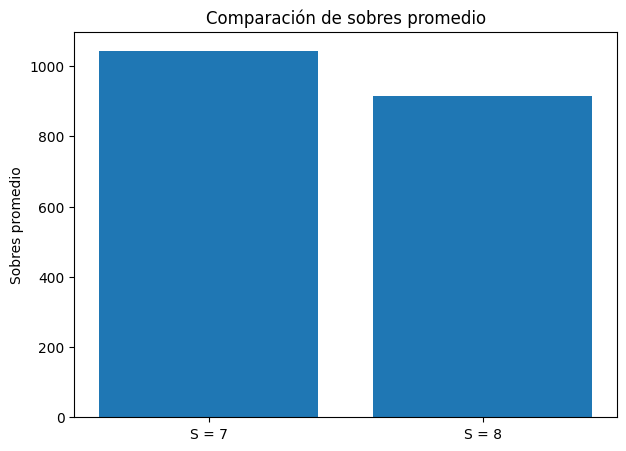

In [6]:
# -------------------------
# Función para distintos S
# -------------------------

def completar_album_variableS(N, S):

    album = set()

    sobres = 0

    while len(album) < N:

        sobres += 1

        sobre = np.random.randint(1, N + 1, S)

        album.update(sobre)

    return sobres

# -------------------------
# Comparación S
# -------------------------

sobres_S7 = []
sobres_S8 = []

for _ in range(R):

    sobres_S7.append(completar_album_variableS(N, 7))

    sobres_S8.append(completar_album_variableS(N, 8))

media_S7 = np.mean(sobres_S7)

media_S8 = np.mean(sobres_S8)

print(f"Media con S=7: {media_S7:.2f}")

print(f"Media con S=8: {media_S8:.2f}")

reduccion = ((media_S7 - media_S8) / media_S7) * 100

print(f"Reducción porcentual: {reduccion:.2f}%")



# -------------------------
# Gráfica comparación
# -------------------------

labels = ["S = 7", "S = 8"]

medias = [media_S7, media_S8]

plt.figure(figsize=(7,5))

plt.bar(labels, medias)

plt.ylabel("Sobres promedio")

plt.title("Comparación de sobres promedio")

plt.show()

## Respuesta — Pregunta 5

Aumentar el número de estampas por sobre reduce significativamente el número esperado de sobres necesarios para completar el álbum.

Esto ocurre porque cada sobre aporta más información nueva y disminuye la frecuencia relativa de repetidas.

# Conclusión final

1. El álbum real requiere una gran cantidad de sobres debido al efecto de estampas repetidas.

2. La probabilidad de completar el álbum con cantidades fijas de sobres puede ser relativamente baja incluso para números grandes.

3. Los intercambios de repetidas ayudan significativamente a reducir costos y sobres necesarios.

4. Incrementar el número de estampas por sobre también mejora considerablemente la eficiencia del proceso.

5. Las simulaciones Monte Carlo permiten estudiar escenarios complejos difíciles de resolver analíticamente.